ЧАСТЬ 1: ГЕНЕТИЧЕСКИЙ АЛГОРИТМ ДЛЯ ЗАДАЧИ КОММИВОЯЖЁРА

Начальная популяция:
  1. Маршрут: 1 -> 2 -> 4 -> 5 -> 3 -> 1, Длина: 23
  2. Маршрут: 1 -> 4 -> 3 -> 5 -> 2 -> 1, Длина: 25
  3. Маршрут: 4 -> 3 -> 1 -> 2 -> 5 -> 4, Длина: 28
  4. Маршрут: 5 -> 1 -> 2 -> 3 -> 4 -> 5, Длина: 30
  Поколение 1: Новый лучший маршрут! Длина: 23
  1 -> 2 -> 4 -> 5 -> 3 -> 1

Лучший найденный маршрут после 10 поколений:
  1 -> 2 -> 4 -> 5 -> 3 -> 1
Длина лучшего маршрута: 23


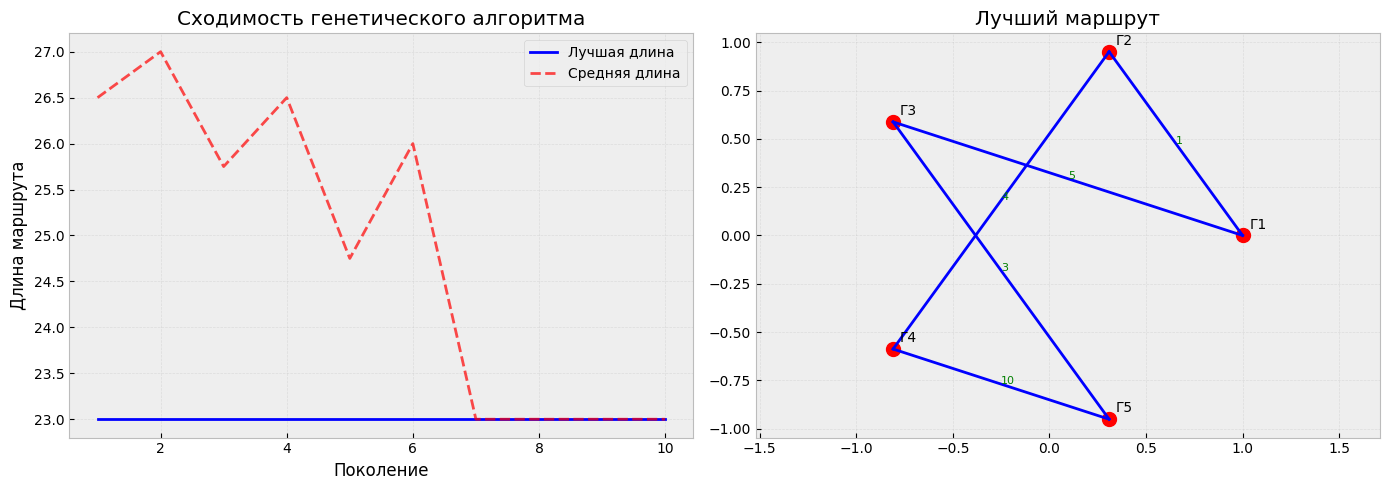

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Настройка визуализации
plt.style.use('bmh')
plt.rc('xtick', labelsize=10); plt.rc('ytick', labelsize=10)

# ==========================================
# ЧАСТЬ 1. ГЕНЕТИЧЕСКИЙ АЛГОРИТМ (ЗАДАЧА КОММИВОЯЖЁРА)
# ==========================================
print("=" * 60)
print("ЧАСТЬ 1: ГЕНЕТИЧЕСКИЙ АЛГОРИТМ ДЛЯ ЗАДАЧИ КОММИВОЯЖЁРА")
print("=" * 60)

# Матрица расстояний (Вариант 1)
DIST_MATRIX = np.array([
    [0, 1, 5, 9, 2],
    [1, 0, 9, 4, 4],
    [5, 9, 0, 8, 3],
    [9, 4, 8, 0, 10],
    [2, 4, 3, 10, 0]
])

CITY_NAMES = ['Город 1', 'Город 2', 'Город 3', 'Город 4', 'Город 5']
N_CITIES = len(DIST_MATRIX)
POP_SIZE = 4 # число особей, увеличить для стабилизации
MUTATION_RATE = 0.01 # вероятность мутации
GENERATIONS = 10 # количество поколений


def calculate_route_length(route):
    """Вычисляет длину замкнутого маршрута."""
    length = 0
    for i in range(len(route)):
        from_city = route[i]
        to_city = route[(i + 1) % len(route)]
        length += DIST_MATRIX[from_city][to_city]
    return length


def create_initial_population(pop_size, n_cities):
    """Создает начальную популяцию случайных перестановок."""
    return [random.sample(range(n_cities), n_cities) for _ in range(pop_size)]


def selection_roulette(population, fitness):
    """
    Оператор отбора (рулетка). Чем меньше длина маршрута, тем выше вероятность.
    Возвращает индексы двух разных родителей.
    """
    max_fitness = float(max(fitness))
    if max_fitness == min(fitness):
        probs = [1.0/len(fitness)] * len(fitness)
    else:
        inv_fitness: list[float] = [(max_fitness - float(f) + 1.0) for f in fitness]
        total_fitness = sum(inv_fitness)
        probs = [f / total_fitness for f in inv_fitness]

    idx1 = np.random.choice(len(population), p=probs)
    idx2 = np.random.choice(len(population), p=probs)
    while idx2 == idx1 and len(population) > 1:
        idx2 = np.random.choice(len(population), p=probs)
    return idx1, idx2


def crossover_tsp(parent1, parent2):
    """
    Двухточечный оператор скрещивания для перестановок
    (строго по методичке, стр. 25).
    """
    size = len(parent1)
    point1, point2 = sorted(random.sample(range(size), 2))

    def two_point_child(p1, p2):
        # Шаг 1: берём фрагмент от p2 между точками разрыва
        fragment = p2[point1:point2+1]
        child = [None] * size
        child[point1:point2+1] = fragment

        # Шаг 2: заполняем звёздочки по p1
        # Начинаем со второго гена выделенного фрагмента p1, идём по кругу
        start_pos = (point1 + 1) % size
        idx = start_pos

        for _ in range(size):
            gene = p1[idx]
            if gene not in child:
                # Ищем первую свободную позицию
                for j in range(size):
                    if child[j] is None:
                        child[j] = gene
                        break
            idx = (idx + 1) % size

        return child

    child1 = two_point_child(parent1, parent2)
    child2 = two_point_child(parent2, parent1)
    return child1, child2


def mutation_swap(route, mutation_rate):
    """Мутация: обмен двух случайных городов."""
    mutated = route.copy()
    if random.random() < mutation_rate:
        idx1, idx2 = random.sample(range(len(route)), 2)
        mutated[idx1], mutated[idx2] = mutated[idx2], mutated[idx1]
    return mutated


def genetic_algorithm(generations=GENERATIONS, verbose=True):
    """Запускает генетический алгоритм."""
    best_overall_route = list()
    population = create_initial_population(POP_SIZE, N_CITIES)
    best_overall_length = float('inf')
    history_best = []
    history_avg = []

    if verbose:
        print("\nНачальная популяция:")
        for i, route in enumerate(population):
            length = calculate_route_length(route)
            route_str = ' -> '.join(str(c+1) for c in route) + f' -> {route[0]+1}'
            print(f"  {i+1}. Маршрут: {route_str}, Длина: {length}")

    for gen in range(generations):
        fitness = [calculate_route_length(route) for route in population]
        avg_length = sum(fitness) / len(fitness)
        history_avg.append(avg_length)

        min_idx = np.argmin(fitness)
        min_length = fitness[min_idx]

        if min_length < best_overall_length:
            best_overall_length = min_length
            best_overall_route = population[min_idx].copy()
            if verbose:
                route_str = ' -> '.join(str(c + 1) for c in best_overall_route) + f' -> {best_overall_route[0] + 1}'
                print(f"  Поколение {gen+1}: Новый лучший маршрут! Длина: {min_length}")
                print(f"  {route_str}")

        history_best.append(min_length)

        new_population = [population[min_idx].copy()]  # элитизм

        while len(new_population) < POP_SIZE:
            p1_idx, p2_idx = selection_roulette(population, fitness)
            child1, child2 = crossover_tsp(population[p1_idx], population[p2_idx])
            child1 = mutation_swap(child1, MUTATION_RATE)
            child2 = mutation_swap(child2, MUTATION_RATE)
            new_population.append(child1)
            if len(new_population) < POP_SIZE:
                new_population.append(child2)

        population = new_population

    if verbose:
        print(f"\nЛучший найденный маршрут после {generations} поколений:")
        route_str = ' -> '.join(str(c+1) for c in best_overall_route) + f' -> {best_overall_route[0]+1}'
        print(f"  {route_str}")
        print(f"Длина лучшего маршрута: {best_overall_length}")

    # Визуализация сходимости
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    generations_range = range(1, generations+1)

    ax1.plot(generations_range, history_best, 'b-', label='Лучшая длина')
    ax1.plot(generations_range, history_avg, 'r--', label='Средняя длина', alpha=0.7)
    ax1.set_title('Сходимость генетического алгоритма')
    ax1.set_xlabel('Поколение')
    ax1.set_ylabel('Длина маршрута')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Схематичное отображение лучшего маршрута
    angles = [2 * math.pi * i / N_CITIES for i in range(N_CITIES)]
    cities_x = np.array([math.cos(a) for a in angles])
    cities_y = np.array([math.sin(a) for a in angles])
    for i in range(N_CITIES):
        ax2.plot(cities_x[i], cities_y[i], 'ro', markersize=10)
        ax2.annotate(f'Г{i+1}', (cities_x[i], cities_y[i]), xytext=(5, 5), textcoords='offset points')
    for i in range(N_CITIES):
        from_city = best_overall_route[i]
        to_city = best_overall_route[(i+1) % N_CITIES]
        ax2.plot([cities_x[from_city], cities_x[to_city]],
                 [cities_y[from_city], cities_y[to_city]], 'b-')
        mid_x = (cities_x[from_city] + cities_x[to_city]) / 2
        mid_y = (cities_y[from_city] + cities_y[to_city]) / 2
        dist_value = int(DIST_MATRIX[from_city][to_city])
        ax2.annotate(f'{dist_value}', (mid_x, mid_y),
                     color='green', fontsize=8)
    ax2.set_title('Лучший маршрут')
    ax2.axis('equal')
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return best_overall_route, best_overall_length, history_best


best_route_ga, best_length_ga, _ = genetic_algorithm()


ЧАСТЬ 2: МУРАВЬИНЫЙ АЛГОРИТМ ДЛЯ ПОИСКА ПУТИ
Итерация 1/10: Лучшая длина: 32, Средняя длина: 51.8, Успешных муравьев: 4/4
Итерация 2/10: Лучшая длина: 32, Средняя длина: 41.5, Успешных муравьев: 4/4
Итерация 3/10: Лучшая длина: 32, Средняя длина: 32.0, Успешных муравьев: 4/4
Итерация 4/10: Лучшая длина: 32, Средняя длина: 53.5, Успешных муравьев: 4/4
Итерация 5/10: Лучшая длина: 32, Средняя длина: 33.8, Успешных муравьев: 4/4
Итерация 6/10: Лучшая длина: 32, Средняя длина: 41.5, Успешных муравьев: 4/4
Итерация 7/10: Лучшая длина: 32, Средняя длина: 34.0, Успешных муравьев: 4/4
Итерация 8/10: Лучшая длина: 32, Средняя длина: 32.0, Успешных муравьев: 4/4
Итерация 9/10: Лучшая длина: 32, Средняя длина: 33.8, Успешных муравьев: 4/4
Итерация 10/10: Лучшая длина: 32, Средняя длина: 32.0, Успешных муравьев: 4/4

Лучший найденный путь: A -> E -> C -> D -> G
Длина лучшего пути: 32


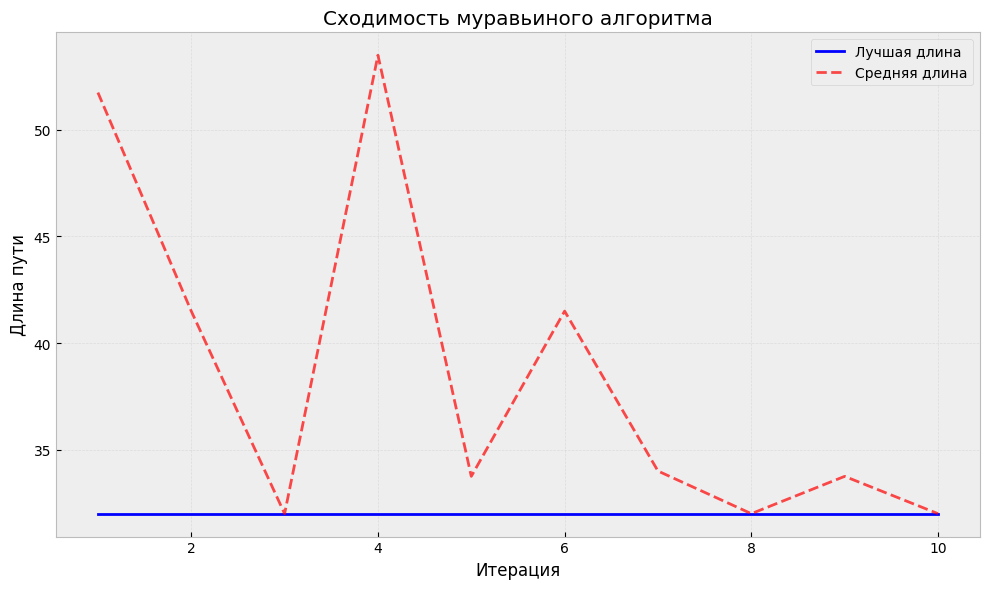

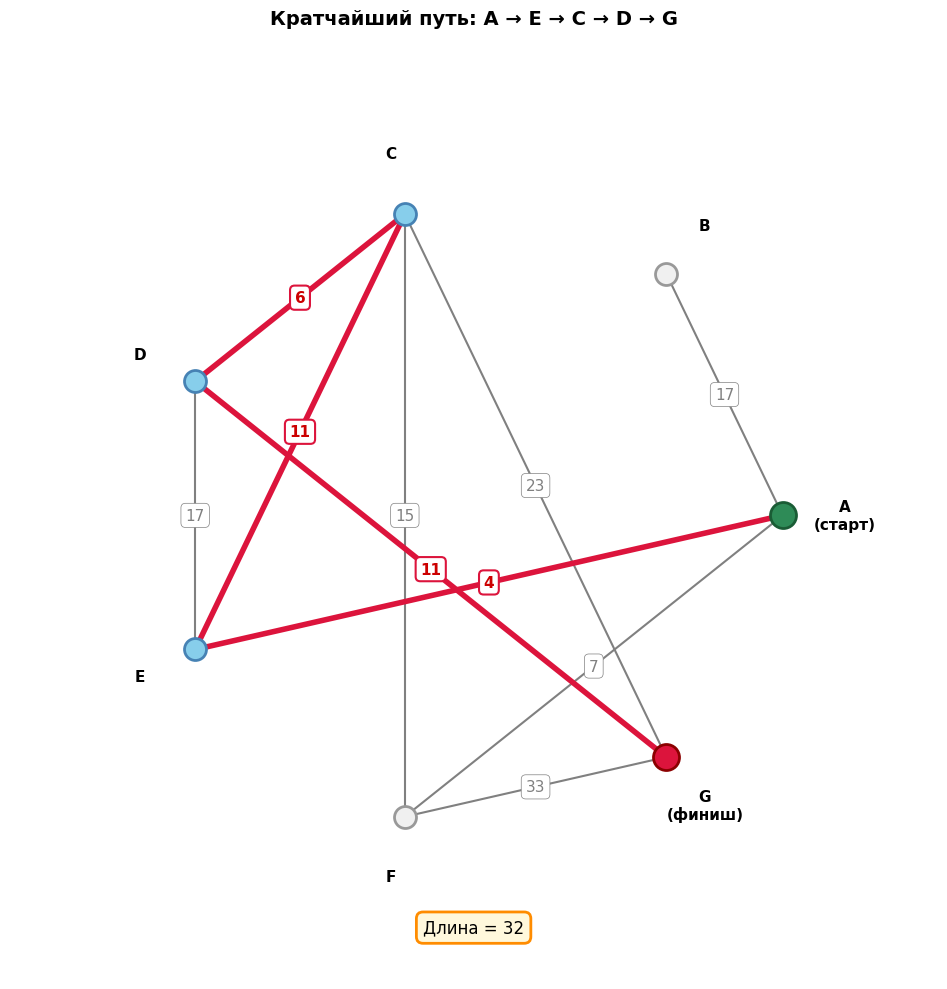


ИТОГОВОЕ СРАВНЕНИЕ РЕЗУЛЬТАТОВ
Метод                              Результат           
-------------------------------------------------------
Генетический алгоритм (TSP)        18                  
Муравьиный алгоритм (Path)         32                  


In [67]:
# ==========================================
# ЧАСТЬ 2. МУРАВЬИНЫЙ АЛГОРИТМ (ПОИСК ПУТИ В ГРАФЕ)
# ==========================================
print("\n" + "=" * 60)
print("ЧАСТЬ 2: МУРАВЬИНЫЙ АЛГОРИТМ ДЛЯ ПОИСКА ПУТИ")
print("=" * 60)

# Граф для Варианта 1
GRAPH = {
    'A': {'B': 17, 'E': 4, 'F': 7},
    'B': {'A': 17},
    'C': {'D': 6, 'E': 11, 'F': 15, 'G': 23},
    'D': {'C': 6, 'E': 17, 'G': 11},
    'E': {'A': 4, 'C': 11, 'D': 17},
    'F': {'A': 7, 'C': 15, 'G': 33},
    'G': {'C': 23, 'D': 11, 'F': 33}
}
START_NODE = 'A'
END_NODE = 'G'

# Параметры муравьиного алгоритма
N_ANTS = 4             # Количество муравьёв
N_ITERATIONS = 10        # Количество итераций (дней)
EVAPORATION_RATE = 0.1   # Коэффициент испарения феромона (ρ)
ALPHA = 1.0              # Важность феромона (α)
BETA = 2.0               # Важность эвристики (β)
Q = 80                   # Количество откладываемого феромона
INIT_PHEROMONE = 1.0     # Начальное значение феромона


def initialize_pheromone(graph, init_value):
    """Инициализирует феромон на всех ребрах графа."""
    pheromone = {}
    for node in graph:
        pheromone[node] = {}
        for neighbor in graph[node]:
            pheromone[node][neighbor] = init_value
    return pheromone


def calculate_path_length(path, graph):
    """Вычисляет длину пути в графе."""
    length = 0
    for i in range(len(path) - 1):
        length += graph[path[i]][path[i+1]]
    return length


def ant_colony_optimization():
    """Запускает муравьиный алгоритм."""
    pheromone = initialize_pheromone(GRAPH, INIT_PHEROMONE)

    best_path = None
    best_path_length = float('inf')
    history_best = []
    history_avg = []

    for iteration in range(N_ITERATIONS):
        paths = []
        path_lengths = []

        for ant in range(N_ANTS):
            path = [START_NODE]
            current_node = START_NODE
            visited = {START_NODE}

            while current_node != END_NODE:
                unvisited_neighbors = [n for n in GRAPH[current_node] if n not in visited]
                if not unvisited_neighbors:
                    break

                desirability = np.array([(1.0 / GRAPH[str(current_node)][str(n)])**BETA for n in unvisited_neighbors])
                pheromone_level = np.array([pheromone[current_node][n]**ALPHA for n in unvisited_neighbors])
                attractiveness = pheromone_level * desirability
                probs = attractiveness / attractiveness.sum()
                next_node = random.choices(unvisited_neighbors, weights=probs, k=1)[0]

                path.append(next_node)
                visited.add(next_node)
                current_node = next_node

            if path[-1] == END_NODE:
                path_len = calculate_path_length(path, GRAPH)
                paths.append(path)
                path_lengths.append(path_len)
                if path_len < best_path_length:
                    best_path_length = path_len
                    best_path = path.copy()

        # Испарение феромона
        for node in GRAPH:
            for neighbor in GRAPH[node]:
                pheromone[node][neighbor] *= (1 - EVAPORATION_RATE)
                pheromone[node][neighbor] = max(pheromone[node][neighbor], 0.01)

        # Откладывание феромона успешными муравьями
        for i, path in enumerate(paths):
            deposit = Q / path_lengths[i]
            for j in range(len(path) - 1):
                u, v = path[j], path[j+1]
                pheromone[u][v] += deposit

        # Сохранение статистики
        if paths:
            history_best.append(best_path_length)
            history_avg.append(np.mean(path_lengths))
        else:
            history_best.append(history_best[-1] if history_best else float('inf'))
            history_avg.append(history_avg[-1] if history_avg else float('inf'))

        avg_len = float(np.mean(path_lengths)) if path_lengths else 0.0
        print(f"Итерация {iteration+1}/{N_ITERATIONS}: "
              f"Лучшая длина: {best_path_length}, "
              f"Средняя длина: {avg_len:.1f}, "
              f"Успешных муравьев: {len(paths)}/{N_ANTS}")


    if best_path is not None:
        print(f"\nЛучший найденный путь: {' -> '.join(best_path)}")
        print(f"Длина лучшего пути: {best_path_length}")
    else:
        print("\nПуть не найден!")
        print(f"Длина лучшего пути: {best_path_length}")

    # Визуализация
    fig, ax = plt.subplots(figsize=(10, 6))
    iterations_range = range(1, N_ITERATIONS+1)
    ax.plot(iterations_range, history_best, 'b-', label='Лучшая длина', linewidth=2)
    ax.plot(iterations_range, history_avg, 'r--', label='Средняя длина', alpha=0.7)
    ax.set_title('Сходимость муравьиного алгоритма')
    ax.set_xlabel('Итерация')
    ax.set_ylabel('Длина пути')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return best_path, best_path_length, history_best


# Запуск муравьиного алгоритма
best_path_aco, best_length_aco, _ = ant_colony_optimization()

# ==========================================
# ОТРИСОВКА ГРАФА С КРАТЧАЙШИМ ПУТЁМ
# ==========================================
import math

def draw_graph_with_path(graph, path, start_node, end_node):
    """
    Рисует граф: все рёбра серым, оптимальный путь — малиновым.
    """
    nodes = list(graph.keys())
    n = len(nodes)

    # Круговое расположение вершин
    angles = {node: 2 * math.pi * i / n for i, node in enumerate(nodes)}
    pos = {node: (math.cos(angles[node]), math.sin(angles[node])) for node in nodes}
    labels_pos = {node: (1.2 * math.cos(angles[node]), 1.2 * math.sin(angles[node]))
                  for node in nodes}

    fig, ax = plt.subplots(figsize=(10, 10))

    # Рёбра, входящие в оптимальный путь
    path_edges = set()
    if path:
        for i in range(len(path) - 1):
            u, v = path[i], path[i+1]
            path_edges.add(tuple(sorted([u, v])))

    # Рисуем ВСЕ рёбра графа
    drawn_edges = set()
    for u in graph:
        for v in graph[u]:
            edge = tuple(sorted([u, v]))
            if edge not in drawn_edges:
                drawn_edges.add(edge)
                x1, y1 = pos[u]
                x2, y2 = pos[v]

                if edge in path_edges:
                    # Рёбра пути — малиновые, толстые
                    color = '#DC143C'
                    lw = 4
                    z = 5
                else:
                    # Остальные — серые, тонкие
                    color = 'gray'
                    lw = 1.5
                    z = 1

                ax.plot([x1, x2], [y1, y2], color=color, linewidth=lw, zorder=z)

                # Подпись веса ребра (всегда на белом фоне)
                mid_x = (x1 + x2) / 2
                mid_y = (y1 + y2) / 2
                weight = graph[u][v]
                ax.annotate(str(weight), (mid_x, mid_y),
                            fontsize=11, fontweight='bold' if edge in path_edges else 'normal',
                            color='#CC0000' if edge in path_edges else 'gray',
                            ha='center', va='center',
                            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                                      edgecolor='#DC143C' if edge in path_edges else 'gray',
                                      alpha=1.0, linewidth=1.5 if edge in path_edges else 0.5),
                            zorder=10)

    # Вершины
    for node in nodes:
        x, y = pos[node]
        if node == start_node:
            color = '#2E8B57'
            edgecolor = '#1a5c35'
            size = 350
            label = f'{node}\n(старт)'
        elif node == end_node:
            color = '#DC143C'
            edgecolor = '#8B0000'
            size = 350
            label = f'{node}\n(финиш)'
        else:
            color = '#87CEEB' if path and node in path else '#F0F0F0'
            edgecolor = '#4682B4' if path and node in path else '#999'
            size = 250
            label = node

        ax.scatter(x, y, s=size, c=color, edgecolors=edgecolor, linewidths=2, zorder=10)
        lx, ly = labels_pos[node]
        ax.annotate(label, (lx, ly), fontsize=11, fontweight='bold',
                    ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                              edgecolor='none', alpha=0.8))

    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.axis('off')

    if path:
        total = sum(graph[path[i]][path[i+1]] for i in range(len(path)-1))
        ax.set_title(f'Кратчайший путь: {" → ".join(path)}', fontsize=14, fontweight='bold', pad=20)
        ax.text(0, -1.35, f'Длина = {total}', fontsize=12, ha='center',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF8DC', edgecolor='#FF8C00', linewidth=2))

    plt.tight_layout()
    plt.show()

# Рисуем граф с найденным путём
if best_path_aco:
    draw_graph_with_path(GRAPH, best_path_aco, START_NODE, END_NODE)


print("\n" + "=" * 60)
print("ИТОГОВОЕ СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("=" * 60)
print(f"{'Метод':<35}{'Результат':<20}")
print("-" * 55)
if best_route_ga:
    print(f"{'Генетический алгоритм (TSP)':<35}{best_length_ga:<20}")
if best_path_aco:
    print(f"{'Муравьиный алгоритм (Path)':<35}{best_length_aco:<20}")